# QuDiPy Conditional Sequence Playback

Plays multiple pulse sequences simultaneously based on pulses generated with QuDiPy. Starts with the GHZ state prep, then into a readout sequence, followed by a simulated trigger and a conditional X gate. For this notebook, the outputs are being viewed on the LeCroy scope. The QRM outputs O1 and O2 are connected to inputs I1 and I2 respectively. QCM outputs O1, O2, O3 and O4 are connected to the scope. The scope should be set to 1MOhm input impedance.

Authors: Noah Stieler, Luke Dyer

In [1]:
import json

import numpy as np
import matplotlib.pyplot as plt

from qblox_instruments import Cluster
from qblox_instruments.types import InstrumentType

In [2]:
#Scan for clusters
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.6.2 with name "cluster-mm" and serial number 00015_2251_003


#### Configure and connect to Qblox modules

In [3]:
cluster = Cluster("cluster_mm", "192.168.137.2")
moduleQRM = None
moduleQCM = None

modules = [mod for mod in cluster.modules if mod.present()]
for mod in modules:
	print(str(mod) + " type=" + str(mod.module_type) + " is_rf_type=" + str(mod.is_rf_type))

cluster.reset()
cluster.get_system_state()

moduleQRM = modules[1]
moduleQCM = modules[0]

moduleQRM.disconnect_outputs()
moduleQRM.disconnect_inputs()
moduleQRM.sequencer0.connect_sequencer("out0_1")	
moduleQRM.sequencer0.sync_en(True)						#Enable wait_sync Q1ASM instruction

moduleQCM.disconnect_outputs()
moduleQCM.sequencer0.connect_sequencer("out0_2")
moduleQCM.sequencer0.sync_en(True)						#Enable wait_sync Q1ASM instruction

<QcmQrm: cluster_mm_module2 of Cluster: cluster_mm> type=QCM is_rf_type=False
<QcmQrm: cluster_mm_module4 of Cluster: cluster_mm> type=QRM is_rf_type=False
<QcmQrm: cluster_mm_module6 of Cluster: cluster_mm> type=QCM is_rf_type=True


# Play 4 Waveforms

In [4]:
def playFourWaveforms(filename: str, waveformNames: list[str]) -> None:

	# Load in pulse data
	pulseData = None
	with open(filename, encoding="utf-8") as file:
		pulseData = json.load(file)
		file.close()

	V_1 = pulseData[waveformNames[0]]
	V_2 = pulseData[waveformNames[1]]
	V_3 = pulseData[waveformNames[2]]
	W_1 = pulseData[waveformNames[3]]

	# Plot the pulses
	fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
	ax.plot(V_1, label=waveformNames[0])
	ax.plot(V_2, label=waveformNames[1])
	ax.plot(V_3, label=waveformNames[2])
	ax.plot(W_1, label=waveformNames[3])
	ax.set_xlabel("Time [s]")
	ax.set_ylabel("Voltage [V]")
	ax.set_title("Resampled Input Pulses")
	ax.legend()
	plt.show()
	
	#Length are in nanoseconds
	waveformLength = len(V_1)

	# Play waveform 0 on first output and waveform 1 on second output and wave for the waveform length
	sequenceProgram = f"""
		wait_sync	4
		play		0,1,{waveformLength}
		stop
	"""

	# Set the waveforms to play on the QRM and QCM
	QRMWaveforms = {
		"V_1" : {"data": V_1, "index": 0},
		"W_1" : {"data": W_1, "index": 1},
	}

	# Waveforms on the QCM are divided by 5 because the QCM module has a range from +/2.5V on a 50Ohm load but this goes to +/- 5.0V on a 1MOhm load
	# The waveforms are a percentage of this range.
	QCMWaveforms = {
		"V_2" : {"data": (np.array(V_2) / 5).tolist(), "index": 0},
		"V_3" : {"data": (np.array(V_3) / 5).tolist(), "index": 1},
	}

	# Upload the JSON files
	moduleQRM.sequencer0.sequence({"waveforms": QRMWaveforms,"weights": {},"acquisitions": {},"program": sequenceProgram})
	moduleQCM.sequencer0.sequence({"waveforms": QCMWaveforms,"weights": {},"acquisitions": {},"program": sequenceProgram})

	# Play the sequences 1000 times
	for i in range(1000):

		moduleQRM.arm_sequencer(0)
		moduleQCM.arm_sequencer(0)

		moduleQRM.start_sequencer()
		moduleQCM.start_sequencer()

		moduleQRM.get_sequencer_state(0)
		moduleQCM.get_sequencer_state(0)

# GHZ Sequence

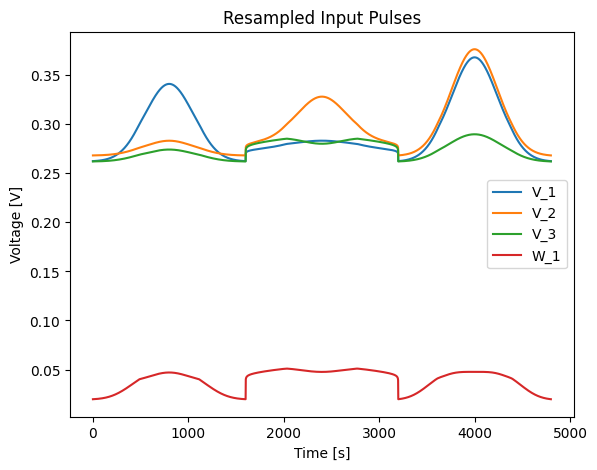

In [5]:
playFourWaveforms("GHZ_prep_example_nodeA.json", ["V_1", "V_2", "V_3", "W_1"])

# Ancilla Readout Sequence

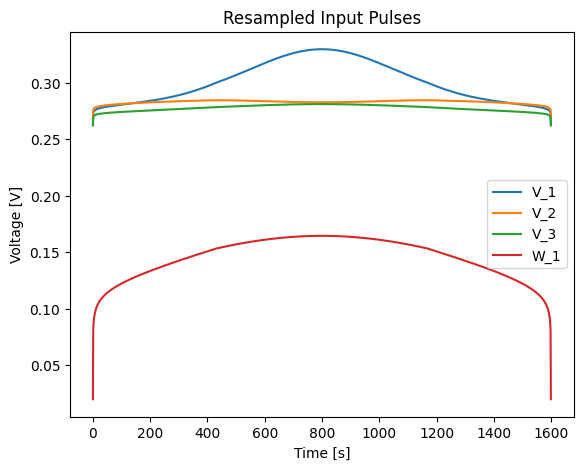

In [6]:
playFourWaveforms("Ancilla_readout_example_nodeA.json", ["V_1", "V_2", "V_3", "W_1"])

# Conditional A1 Gate

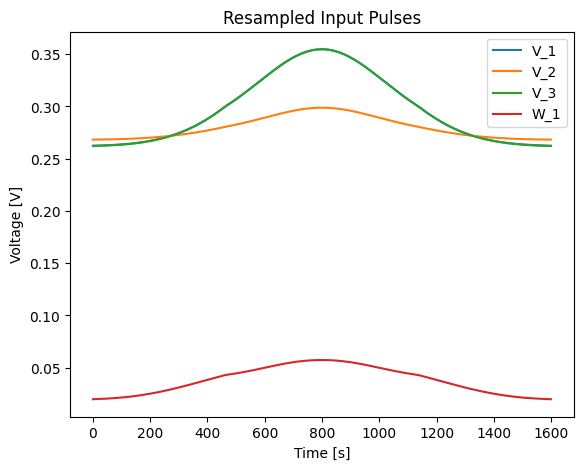

In [7]:
playFourWaveforms("conditional_A1_gate_post_readout_example_nodeA.json", ["V_1", "V_2", "V_3", "W_1"])